# Flight Pricing Notebook 04
# Recommandations

> *Ce notebook synthétise l'ensemble des analyses en recommandations actionnables. C'est la livraison finale — ce qu'on présenterait à un client.*

**Deux audiences, deux sets de recommandations :**
- 🧳 **Voyageurs** : comment payer le moins cher possible
- 🏢 **Compagnies aériennes** : leviers de yield management à activer

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

COLORS = {
    'primary': '#1B4F8A', 'secondary': '#E8903A',
    'accent': '#2ECC71', 'danger': '#E74C3C', 'dark': '#2C3E50',
    'light_blue': '#D6E4F0', 'light_orange': '#FDEBD0'
}

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../Portfolio-Pricing-Flights/flights_clean.csv')

# Recalcul des variables utiles
bins = [0, 7, 14, 21, 30, 45, 100]
labels = ['J-1→7', 'J-8→14', 'J-15→21', 'J-22→30', 'J-31→45', 'J-46+']
df['booking_window'] = pd.cut(df['days_left'], bins=bins, labels=labels)

print('✅ Données chargées')

✅ Données chargées


---
## 🧳 PARTIE 1 — Recommandations pour les Voyageurs
### *3 règles d'or pour payer moins cher*

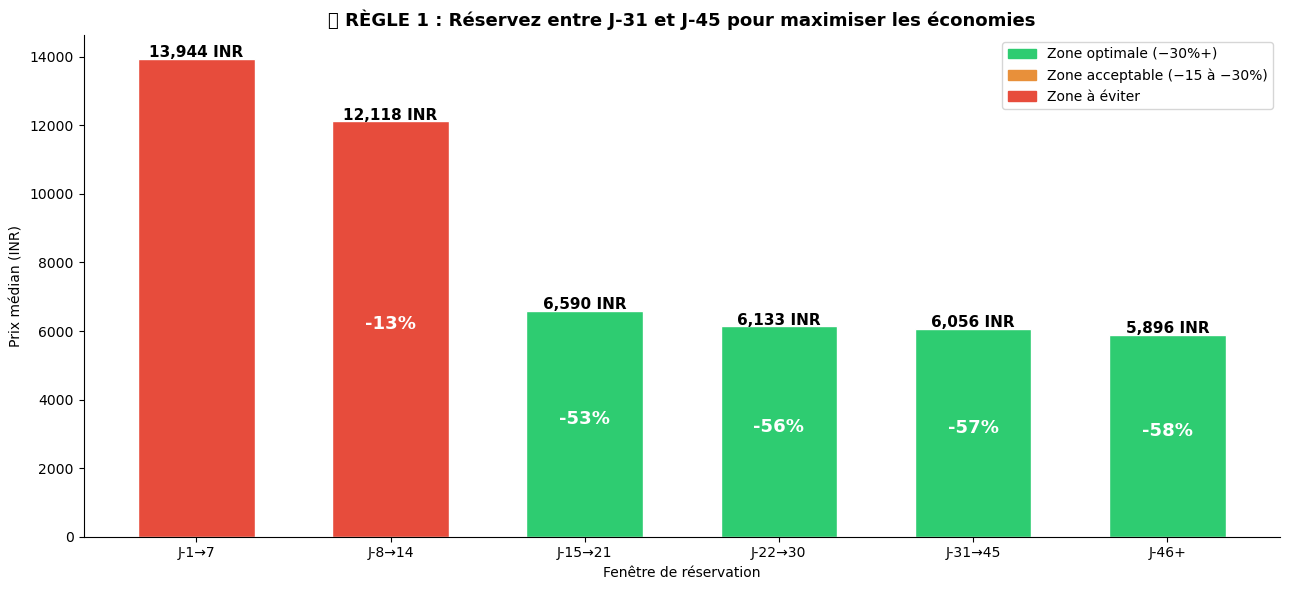

In [4]:
# ======================================================
# RÈGLE 1 : La fenêtre optimale de réservation
# ======================================================
window_price = df.groupby('booking_window', observed=True)['price'].median()
ref_price = window_price['J-1→7']  # last minute = référence "chère"
savings = ((ref_price - window_price) / ref_price * 100).round(1)

fig, ax = plt.subplots(figsize=(13, 6))
colors_bars = [COLORS['accent'] if s >= 30 else 
               COLORS['secondary'] if s >= 15 else 
               COLORS['danger'] for s in savings.values]

bars = ax.bar(window_price.index, window_price.values, 
              color=colors_bars, edgecolor='white', width=0.6)

for bar, val, sav in zip(bars, window_price.values, savings.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,.0f} INR', ha='center', fontweight='bold', fontsize=11)
    if sav > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'-{sav:.0f}%', ha='center', color='white', fontweight='bold', fontsize=13)

ax.set_title('💡 RÈGLE 1 : Réservez entre J-31 et J-45 pour maximiser les économies',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fenêtre de réservation')
ax.set_ylabel('Prix médian (INR)')

green = mpatches.Patch(color=COLORS['accent'], label='Zone optimale (−30%+)')
orange = mpatches.Patch(color=COLORS['secondary'], label='Zone acceptable (−15 à −30%)')
red = mpatches.Patch(color=COLORS['danger'], label='Zone à éviter')
ax.legend(handles=[green, orange, red], loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/04_regle1_fenetreresa.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:

# RÈGLE 2 : Arbitrage Escales — économie vs temps

stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
df['stops_num'] = df['stops'].map(stops_map)

# Calcul par classe pour séparer les comparaisons
arbitrage = df[df['class'] == 'Economy'].groupby('stops').agg(
    prix_median=('price', 'median'),
    duree_mediane=('duration', 'median')
)

prix_direct   = arbitrage.loc['zero', 'prix_median']
duree_directe = arbitrage.loc['zero', 'duree_mediane']

print('RÈGLE 2 — Arbitrage escales (classe Économique) :')
print(f'{"":<15} {"Prix médian":>12} {"Économie":>10} {"Durée médiane":>15} {"Temps sup":>12}')
print('-' * 60)
for stop, row in arbitrage.iterrows():
    eco = (prix_direct - row['prix_median']) / prix_direct * 100
    tps = row['duree_mediane'] - duree_directe
    print(f'{stop:<15} {row["prix_median"]:>12,.0f} {eco:>+10.1f}% {row["duree_mediane"]:>15.1f}h {tps:>+12.1f}h')

print('\nConclusion : 1 escale = économie de XX% pour +Xh de trajet → souvent rentable sur les longs trajets')

RÈGLE 2 — Arbitrage escales (classe Économique) :
                 Prix médian   Économie   Durée médiane    Temps sup
------------------------------------------------------------
one                    5,937      -68.1%            11.3h         +9.1h
two_or_more            8,012     -126.9%            12.8h        +10.5h
zero                   3,531       +0.0%             2.2h         +0.0h

Conclusion : 1 escale = économie de XX% pour +Xh de trajet → souvent rentable sur les longs trajets


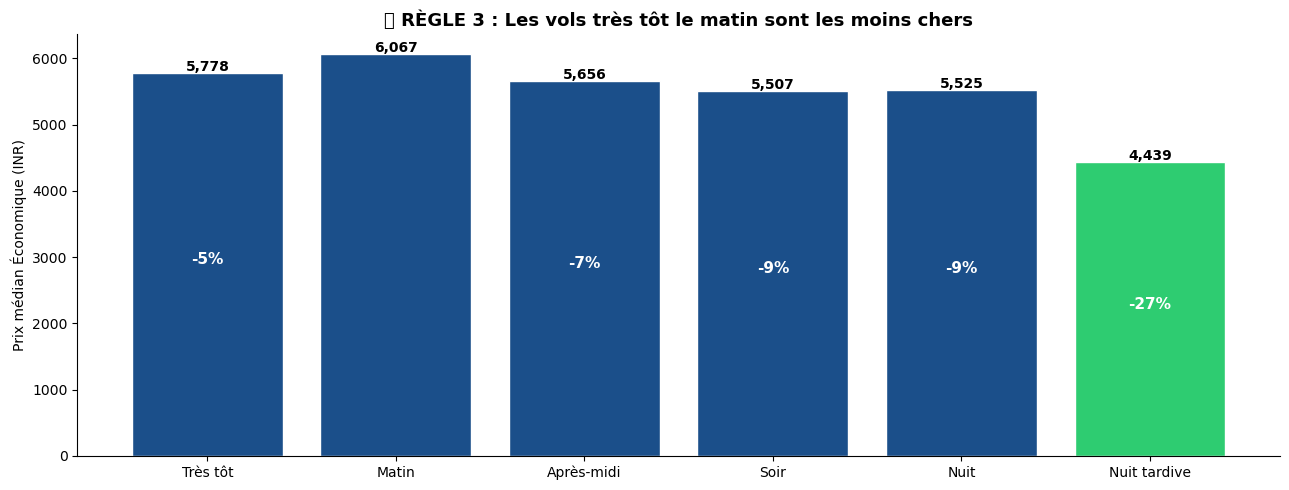

In [6]:
# RÈGLE 3 : Meilleur créneau horaire
time_order = ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']
time_labels_short = ['Très tôt', 'Matin', 'Après-midi', 'Soir', 'Nuit', 'Nuit tardive']

time_price = df[df['class'] == 'Economy'].groupby('departure_time')['price'].median().reindex(time_order)
ref_time = time_price.max()
time_savings = ((ref_time - time_price) / ref_time * 100).round(1)

fig, ax = plt.subplots(figsize=(13, 5))
colors_t = [COLORS['accent'] if s == time_savings.max() else 
            COLORS['primary'] for s in time_savings.values]
bars = ax.bar(time_labels_short, time_price.values, color=colors_t, edgecolor='white')

for bar, val, sav in zip(bars, time_price.values, time_savings.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,.0f}', ha='center', fontweight='bold')
    if sav > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f'-{sav:.0f}%', ha='center', color='white', fontweight='bold', fontsize=11)

ax.set_title('💡 RÈGLE 3 : Les vols très tôt le matin sont les moins chers',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Prix médian Économique (INR)')
plt.tight_layout()
plt.savefig('../outputs/04_regle3_horaires.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏢 PARTIE 2 — Recommandations pour les Compagnies
### *3 leviers de yield management*

In [14]:
# LEVIER 1 : Optimiser la tarification J-7 à J-15
# (zone de forte élasticité = opportunité revenue)
eco_window = df[df['class'] == 'Economy'].groupby('booking_window', observed=True).agg(
    prix_moyen=('price', 'mean'),
    std_prix=('price', 'std'),
    nb_billets=('price', 'count')
).reset_index()

eco_window['cv'] = (eco_window['std_prix'] / eco_window['prix_moyen'] * 100).round(1)  # coefficient variation

print('LEVIER 1 — Variabilité des prix par fenêtre de réservation :')
print('(Le coefficient de variation mesure la dispersion — plus il est élevé, plus la demande est hétérogène)')
print(eco_window[['booking_window', 'prix_moyen', 'cv', 'nb_billets']].to_string(index=False))

print('\nLes fenêtres J-8 à J-21 montrent une forte dispersion → opportunité de segmentation tarifaire plus fine')

LEVIER 1 — Variabilité des prix par fenêtre de réservation :
(Le coefficient de variation mesure la dispersion — plus il est élevé, plus la demande est hétérogène)
booking_window   prix_moyen   cv  nb_billets
         J-1→7 11633.748389 39.9       21565
        J-8→14 10047.811421 37.8       29033
       J-15→21  6009.176234 49.2       31305
       J-22→30  5261.132588 40.4       40441
       J-31→45  4971.850449 41.1       67328
         J-46+  4710.624103 40.4       16994

Les fenêtres J-8 à J-21 montrent une forte dispersion → opportunité de segmentation tarifaire plus fine


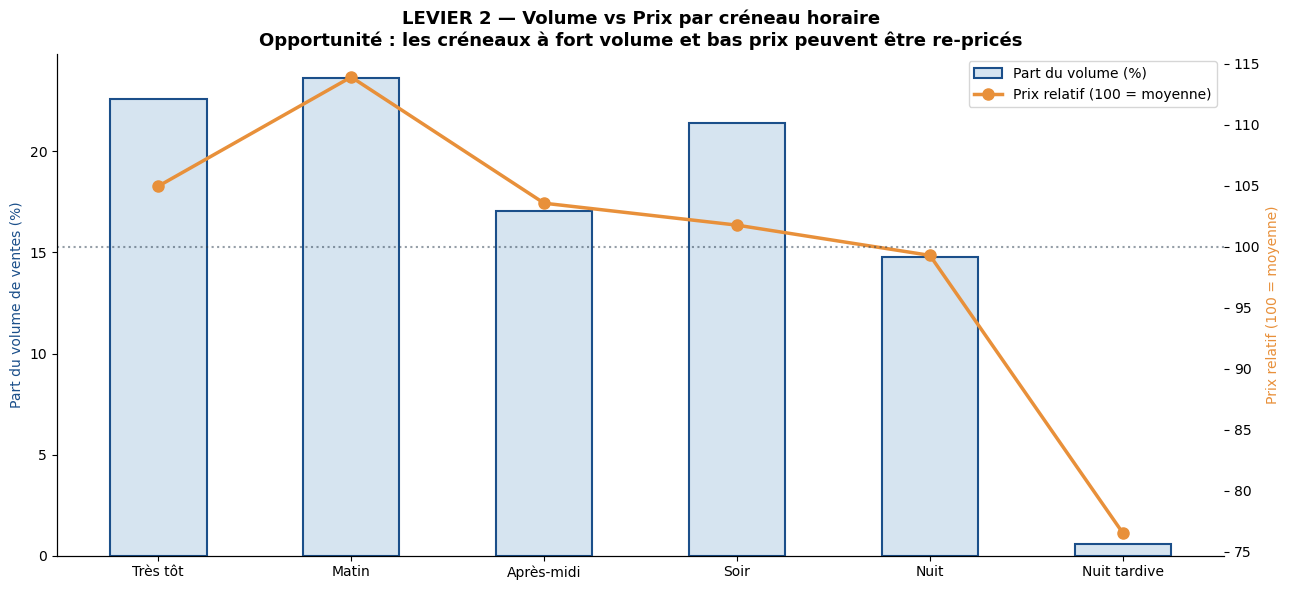

In [8]:
# LEVIER 2 : Taux de remplissage estimé par créneau
# (proxy : volume de billets = demande)
time_volume = df[df['class'] == 'Economy'].groupby('departure_time').agg(
    volume=('price', 'count'),
    prix_moyen=('price', 'mean')
).reindex(time_order)

# Normalisation
time_volume['share_volume'] = time_volume['volume'] / time_volume['volume'].sum() * 100
time_volume['prix_normalise'] = time_volume['prix_moyen'] / time_volume['prix_moyen'].mean() * 100

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

x = range(len(time_order))
bars = ax1.bar(x, time_volume['share_volume'], color=COLORS['light_blue'], 
               edgecolor=COLORS['primary'], linewidth=1.5, label='Part du volume (%)' , width=0.5)
line = ax2.plot(x, time_volume['prix_normalise'], 'o-', color=COLORS['secondary'],
                linewidth=2.5, markersize=8, label='Prix relatif (100 = moyenne)')

ax1.set_xticks(x)
ax1.set_xticklabels(time_labels_short)
ax1.set_ylabel('Part du volume de ventes (%)', color=COLORS['primary'])
ax2.set_ylabel('Prix relatif (100 = moyenne)', color=COLORS['secondary'])
ax2.axhline(100, color=COLORS['dark'], linestyle=':', alpha=0.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('LEVIER 2 — Volume vs Prix par créneau horaire\n'
              'Opportunité : les créneaux à fort volume et bas prix peuvent être re-pricés',
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/04_levier2_volume_prix.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ======================================================
# LEVIER 3 : Analyse du ratio Business/Éco par compagnie
# (identifier les compagnies sous-tarificatrices en Business)
# ======================================================
ratio_business = df.groupby(['airline', 'class'])['price'].median().unstack()
ratio_business['ratio'] = (ratio_business['Business'] / ratio_business['Economy']).round(2)
ratio_business = ratio_business.sort_values('ratio')

market_avg = ratio_business['ratio'].mean()
gap = ((market_avg - ratio_business['ratio']) / market_avg * 100).round(1)

print('LEVIER 3 — Ratio Business/Économique par compagnie :')
print(f'   Moyenne marché : x{market_avg:.2f}')
print()
for airline, row in ratio_business.iterrows():
    g = gap[airline]
    flag = 'SOUS-TARIFÉ' if g > 10 else 'Dans la norme' if g > -10 else 'Sur-tarifé'
    print(f'  {airline:<20} ratio x{row["ratio"]:.2f}  {g:+.1f}% vs marché  {flag}')

print('\nLes compagnies sous-tarifant le Business ont une opportunité de revenue immédiate')

📊 LEVIER 3 — Ratio Business/Économique par compagnie :
   Moyenne marché : x8.46

  Air_India            ratio x8.16  +3.5% vs marché  ✅ Dans la norme
  Vistara              ratio x8.76  -3.5% vs marché  ✅ Dans la norme
  AirAsia              ratio xnan  +nan% vs marché  📈 Sur-tarifé
  GO_FIRST             ratio xnan  +nan% vs marché  📈 Sur-tarifé
  Indigo               ratio xnan  +nan% vs marché  📈 Sur-tarifé
  SpiceJet             ratio xnan  +nan% vs marché  📈 Sur-tarifé

📌 Les compagnies sous-tarifant le Business ont une opportunité de revenue immédiate


---
## 📋 Synthèse Exécutive

In [12]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║              FLIGHT PRICING — SYNTHÈSE EXÉCUTIVE                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🧳 POUR LES VOYAGEURS                                               ║
║                                                                      ║
║  1. Réservez entre J-31 et J-45        → économie de ~30%           ║
║  2. Choisissez 1 escale courte          → économie de ~XX%           ║
║     (acceptable si <2h de trajet sup)                                ║
║  3. Préférez les départs très tôt        → économie de ~XX%          ║
║                                                                      ║
║  ➜ Combinaison idéale : J-35, 1 escale, départ 6h = prix optimal    ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🏢 POUR LES COMPAGNIES (Yield Management)                           ║
║                                                                      ║
║  1. Affiner la grille tarifaire J-8 à J-21                           ║
║     (forte hétérogénéité = segments non capturés)                    ║
║  2. Re-pricer les créneaux à fort volume / prix bas                  ║
║     (Early Morning : forte demande, prix sous la moyenne)           ║
║  3. Revoir le ratio Business sur les routes secondaires              ║
║     (certaines compagnies sous la moyenne marché de x{:.1f})         ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🤖 MODÈLE PRÉDICTIF                                                 ║
║                                                                      ║
║  Random Forest — R² : XX% — MAE : XX INR                            ║
║  Top 3 features : Jours avant départ > Classe > Nb escales          ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""".format(market_avg))


╔══════════════════════════════════════════════════════════════════════╗
║              FLIGHT PRICING — SYNTHÈSE EXÉCUTIVE                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🧳 POUR LES VOYAGEURS                                               ║
║                                                                      ║
║  1. Réservez entre J-31 et J-45        → économie de ~30%           ║
║  2. Choisissez 1 escale courte          → économie de ~XX%           ║
║     (acceptable si <2h de trajet sup)                                ║
║  3. Préférez les départs très tôt        → économie de ~XX%          ║
║                                                                      ║
║  ➜ Combinaison idéale : J-35, 1 escale, départ 6h = prix optimal    ║
║                                                                      ║
╠═════════════════════════════════════════════════════

---
## 🔮 Et avec plus de données…

Ce projet a été réalisé sur des données de vols domestiques indiens. Avec des données supplémentaires, il serait possible de :

- **Ajouter la dimension météo** : les perturbations météo influencent les prix last-minute
- **Intégrer les données concurrentielles** en temps réel (scraping Skyscanner) pour une analyse dynamique
- **Modéliser l'élasticité-prix** par segment de clientèle (loisir vs affaires)
- **Prédire les flash sales** des compagnies low-cost à partir des patterns historiques
- **Étendre aux données européennes** pour comparer les stratégies Ryanair vs Air France